In [37]:
import shap
from utils.data_loader import load_folktables_income_data, load_gbs_gesis
import seaborn as sns
import pandas as pd
import numpy as np
np.random.seed(5)
from utils.sampling import  sample_with_test_set
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from utils.metrics import calculate_feature_importance, train_pu_classifier
from sklearn.model_selection import KFold

In [38]:
df, columns, target = load_folktables_income_data()
df[columns] = StandardScaler().fit_transform(df[columns])
# N = df[df["label"] == 1]
# R = df[df["label"] == 0]
N, R, T = sample_with_test_set(
           "less_positive_class",
           df,
           target,
           train_fraction=0.5,
           bias_fraction=0.1,
           test_fraction=0.1,
           columns=columns,
       )

In [50]:
kf = KFold(n_splits=5, shuffle=True, random_state=5)

for N_train_index, N_test_index in kf.split(N):
    N_train, N_test = N.iloc[N_train_index], N.iloc[N_test_index]
    train = pd.concat([N_train, R])
    clf = train_pu_classifier(train[columns], train.label)
    abs_feature_importance, _ = calculate_feature_importance(
            test_N=N_test[columns].values,
            clf=clf,
        )

In [58]:
sorted_indices = np.argsort(abs_feature_importance)

<Axes: ylabel='None'>

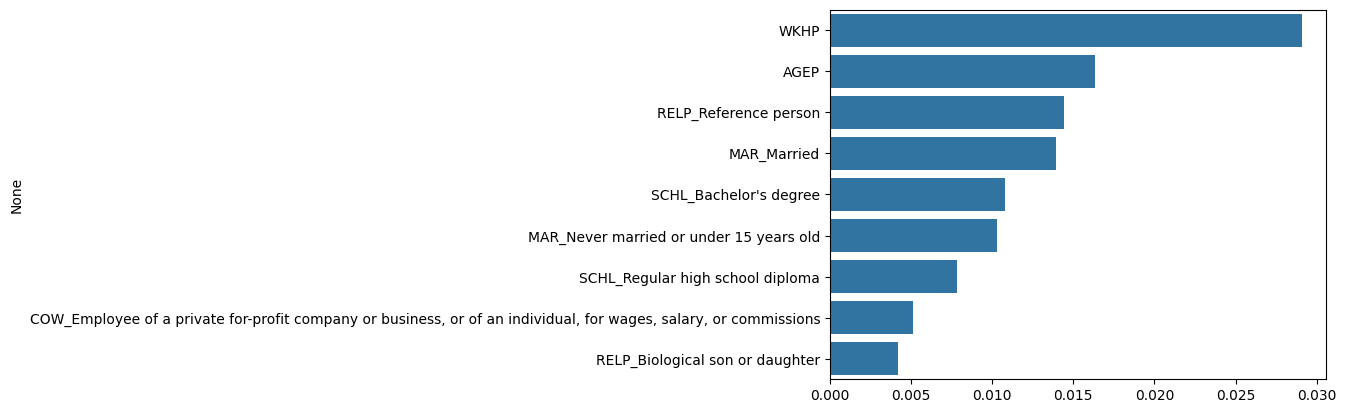

In [63]:
sns.barplot(x=abs_feature_importance[sorted_indices[:-10:-1]], y=columns[sorted_indices[:-10:-1]])